Branch 5 — Commodities & FX
Date range : 1989-11-01 -> 2026-03-13

Asset                          Days         Start     Current        Mean         Max
----------------------------------------------------------------------------------
  Gold                        10284    1990-01-02     5061.70      963.32     5318.40
  Silver                      10284    1990-01-02       80.91       13.88      115.50
  Copper                      10284    1990-01-02      571.45      222.96      620.35
  WTI Crude Oil               10284    1990-01-02       98.71       49.86      145.29
  Brent Crude                 10284    1990-01-02      103.14       51.70      146.08
  Natural Gas                 10206    1990-04-03        3.13        3.69       15.38
  Wheat                       10285    1990-01-02      618.50      472.00     1425.25
  Corn                        10326    1989-11-01      452.50      358.76      831.25
  Soybeans                    10285    1990-01-02     1211.00      873.22   

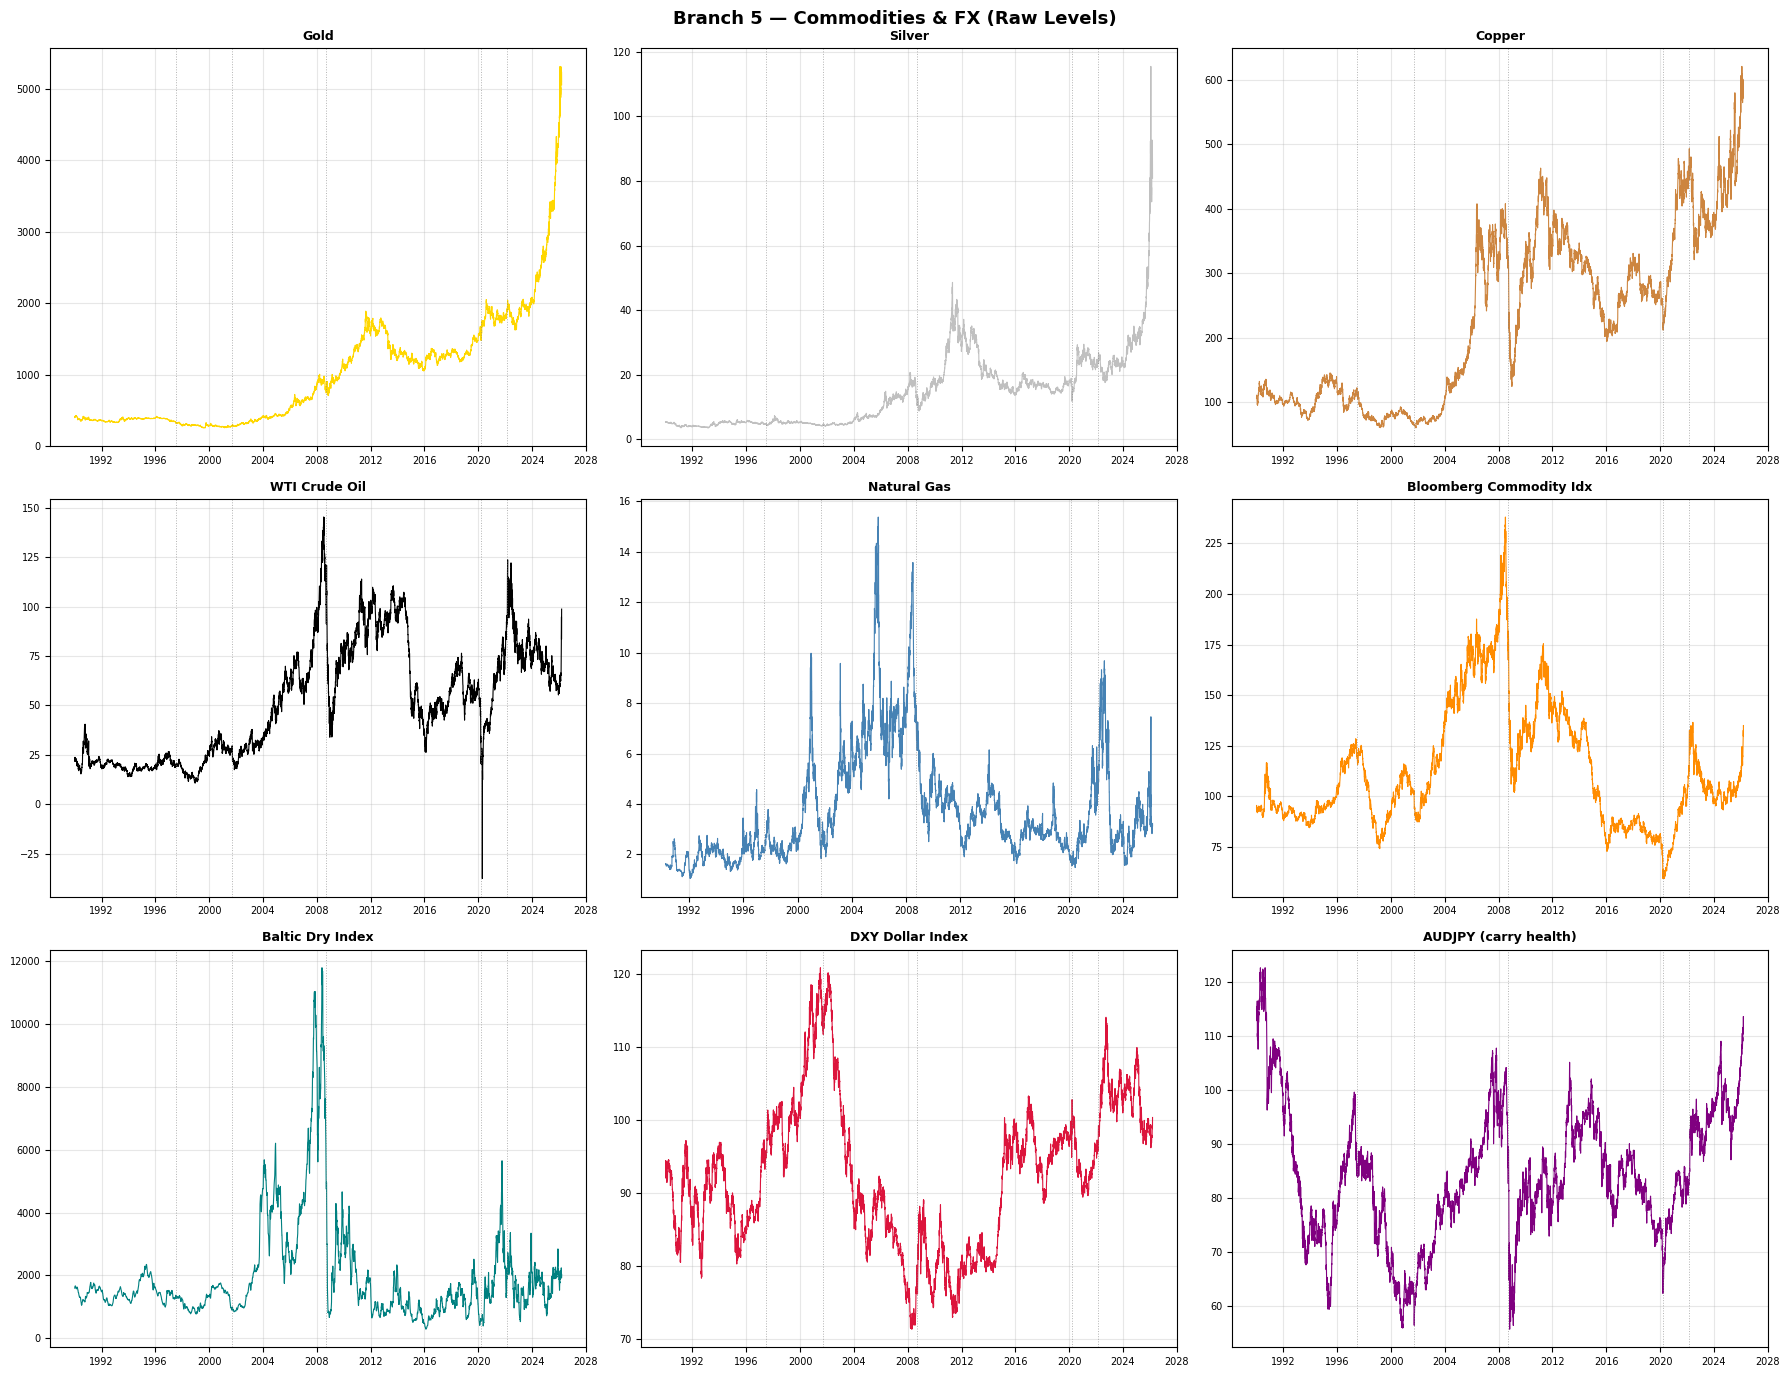


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\06_branch5_raw_levels.png


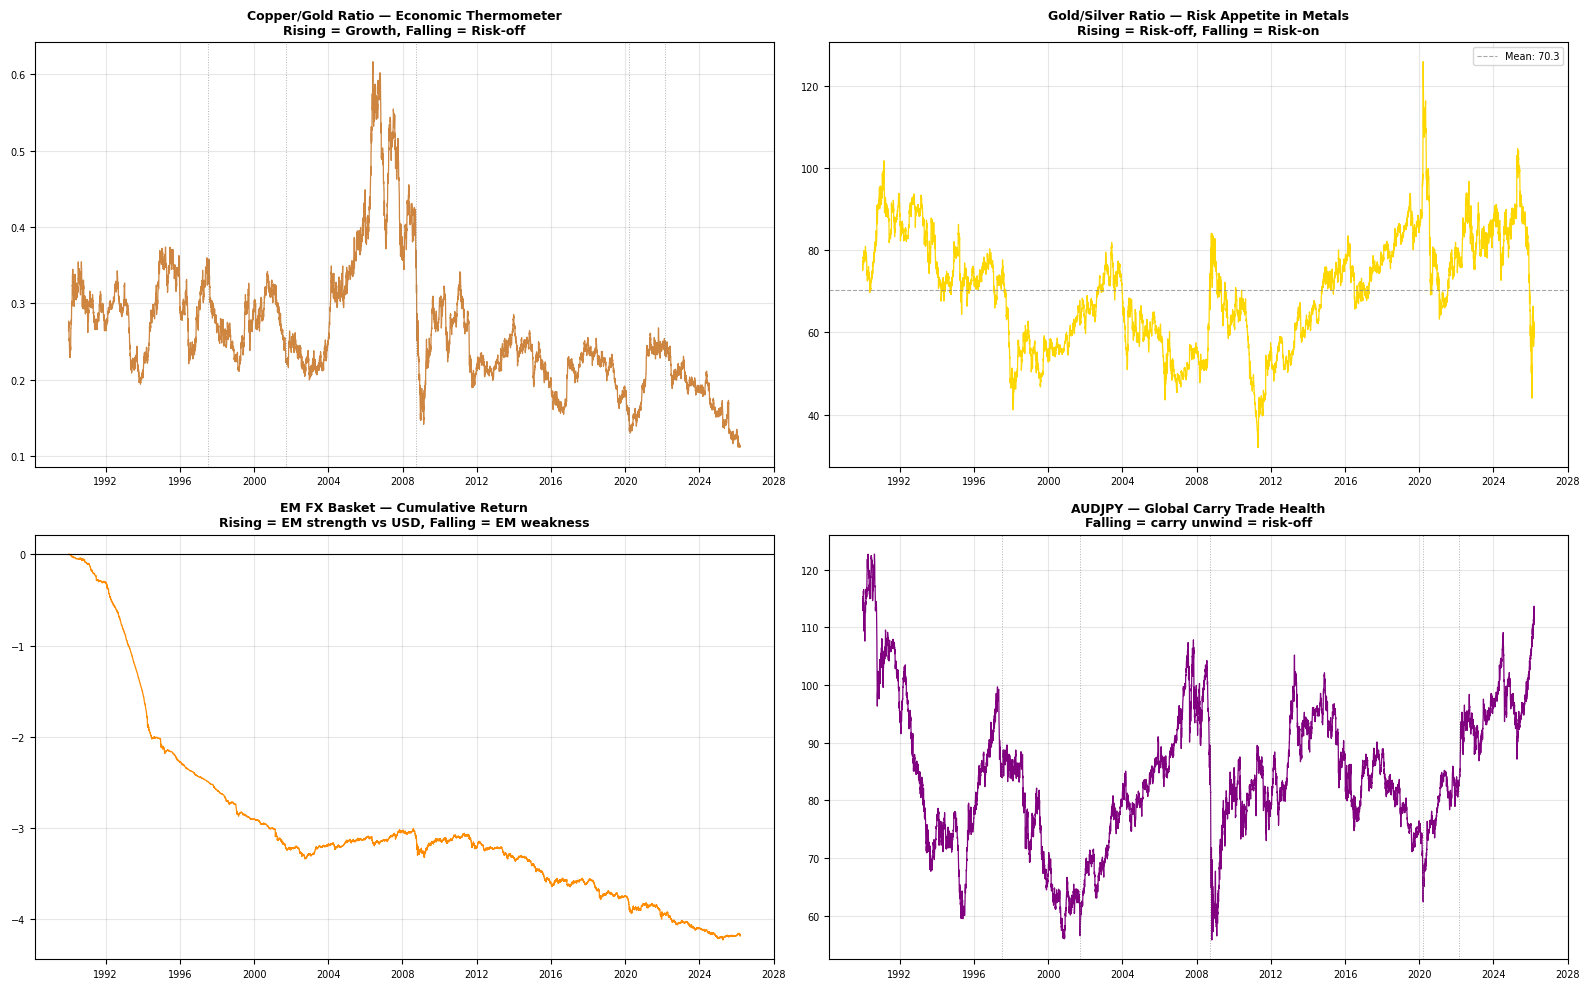

Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\06_branch5_key_ratios.png


In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

# ── Load prices and returns ───────────────────────────────────────────────────
prices  = pd.read_csv(cfg.ALIGNED_PRICES_FILE,  index_col="date", parse_dates=True)
returns = pd.read_csv(cfg.MASTER_RETURNS_FILE,   index_col="date", parse_dates=True)

# ── Define universe ───────────────────────────────────────────────────────────
PRECIOUS_METALS = {
    "GC1 Comdty": "Gold",
    "SI1 Comdty": "Silver",
}

INDUSTRIAL_METALS = {
    "HG1 Comdty": "Copper",
}

ENERGY = {
    "CL1 Comdty": "WTI Crude Oil",
    "CO1 Comdty": "Brent Crude",
    "NG1 Comdty": "Natural Gas",
}

AGRICULTURE = {
    "W1 Index": "Wheat",
    "C1 Index": "Corn",
    "S1 Index": "Soybeans",
}

COMMODITY_INDICES = {
    "BCOM Index": "Bloomberg Commodity Index",
    "BDIY Index": "Baltic Dry Index",
}

SAFE_HAVEN_FX = {
    "USDJPY Curncy": "USDJPY",
    "USDCHF Curncy": "USDCHF",
    "DXY Curncy":    "DXY Dollar Index",
}

COMMODITY_FX = {
    "AUDUSD Curncy": "AUDUSD (AUD)",
    "USDCAD Curncy": "USDCAD (CAD)",
    "NZDUSD Curncy": "NZDUSD (NZD)",
}

MAJOR_FX = {
    "EURUSD Curncy": "EURUSD",
    "GBPUSD Curncy": "GBPUSD",
}

EM_FX = {
    "USDCNY Curncy": "USDCNY (China)",
    "USDINR Curncy": "USDINR (India)",
    "USDBRL Curncy": "USDBRL (Brazil)",
    "USDTRY Curncy": "USDTRY (Turkey)",
    "USDZAR Curncy": "USDZAR (S.Africa)",
    "USDMXN Curncy": "USDMXN (Mexico)",
}

CARRY = {
    "AUDJPY Curncy": "AUDJPY (carry health)",
}

ALL_TICKERS = {
    **PRECIOUS_METALS, **INDUSTRIAL_METALS, **ENERGY,
    **AGRICULTURE, **COMMODITY_INDICES,
    **SAFE_HAVEN_FX, **COMMODITY_FX, **MAJOR_FX,
    **EM_FX, **CARRY
}

# ── Extract prices ────────────────────────────────────────────────────────────
comfx_prices = prices[list(ALL_TICKERS.keys())].copy()
comfx_prices.dropna(how="all", inplace=True)

print("Branch 5 — Commodities & FX")
print("="*70)
print(f"Date range : {comfx_prices.dropna(how='all').index.min().date()} -> "
      f"{comfx_prices.dropna(how='all').index.max().date()}")
print()
print(f"{'Asset':<28} {'Days':>6}  {'Start':>12}  "
      f"{'Current':>10}  {'Mean':>10}  {'Max':>10}")
print("-"*82)
for ticker, name in ALL_TICKERS.items():
    s = comfx_prices[ticker].dropna()
    if not s.empty:
        print(f"  {name:<26} {len(s):>6}  "
              f"{str(s.index.min().date()):>12}  "
              f"{s.iloc[-1]:>10.2f}  "
              f"{s.mean():>10.2f}  "
              f"{s.max():>10.2f}")


# ── Compute key derived signals ───────────────────────────────────────────────

# 1. Copper/Gold ratio — THE economic thermometer
#    Rising = growth expected, Falling = risk-off / recession fear
copper_gold = prices["HG1 Comdty"] / prices["GC1 Comdty"]
copper_gold.name = "Copper/Gold Ratio"

# 2. Gold/Silver ratio — risk appetite within metals
#    Rising = risk-off (gold outperforms silver), Falling = risk-on
gold_silver = prices["GC1 Comdty"] / prices["SI1 Comdty"]
gold_silver.name = "Gold/Silver Ratio"

# 3. WTI/Brent spread — US vs global oil market stress
#    Normally WTI trades at slight discount to Brent
wti_brent = prices["CL1 Comdty"] - prices["CO1 Comdty"]
wti_brent.name = "WTI-Brent Spread"

# 4. DXY vs Gold — when both rise, real stress. When diverge, tells a story
# (tracked separately as levels)

# 5. EM FX basket — equal weight of EM currencies vs USD
#    All quoted as USD per foreign currency OR foreign per USD
#    Need to normalize: USDINR, USDBRL, USDTRY, USDZAR, USDMXN are
#    "USD per EM" so rising = EM weakness
#    USDCNY is also USD per CNY so rising = CNY weakness
em_fx_tickers = list(EM_FX.keys())
em_fx_ret = returns[em_fx_tickers].copy()
# All EM tickers are USD/EM (rising = USD stronger = EM weaker)
# We invert so that rising basket = EM strength
em_fx_basket = -em_fx_ret.mean(axis=1)
em_fx_basket_cumulative = em_fx_basket.cumsum()
em_fx_basket_cumulative.name = "EM FX Basket (positive = EM strength)"

print(f"\nDerived signals (current):")
print("-"*50)
print(f"  Copper/Gold ratio  : {copper_gold.dropna().iloc[-1]:.6f}  "
      f"(mean: {copper_gold.dropna().mean():.6f})")
print(f"  Gold/Silver ratio  : {gold_silver.dropna().iloc[-1]:.2f}  "
      f"(mean: {gold_silver.dropna().mean():.2f})")
print(f"  WTI-Brent spread   : {wti_brent.dropna().iloc[-1]:>+.2f}  "
      f"(mean: {wti_brent.dropna().mean():>+.2f})")


# ── Plot overview ─────────────────────────────────────────────────────────────
CRISES = [
    ("1997-07-02","Asia"),("2001-09-11","9/11"),
    ("2008-09-15","Lehman"),("2020-03-16","Covid"),
    ("2022-02-24","Ukraine"),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

plot_items = [
    ("Gold",                    "GC1 Comdty",    "gold"),
    ("Silver",                  "SI1 Comdty",    "silver"),
    ("Copper",                  "HG1 Comdty",    "peru"),
    ("WTI Crude Oil",           "CL1 Comdty",    "black"),
    ("Natural Gas",             "NG1 Comdty",    "steelblue"),
    ("Bloomberg Commodity Idx", "BCOM Index",    "darkorange"),
    ("Baltic Dry Index",        "BDIY Index",    "teal"),
    ("DXY Dollar Index",        "DXY Curncy",    "crimson"),
    ("AUDJPY (carry health)",   "AUDJPY Curncy", "purple"),
]

for idx, (name, ticker, color) in enumerate(plot_items):
    s  = comfx_prices[ticker].dropna()
    ax = axes[idx]
    ax.plot(s.index, s.values, lw=0.8, color=color)
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)
    for crisis_date, label in CRISES:
        try:
            ax.axvline(pd.Timestamp(crisis_date), color="grey",
                       lw=0.7, ls=":", alpha=0.6)
        except: pass

fig.suptitle("Branch 5 — Commodities & FX (Raw Levels)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "06_branch5_raw_levels.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")


# ── Plot key ratios ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Copper/Gold
ax = axes[0, 0]
cg = copper_gold.dropna()
ax.plot(cg.index, cg.values, lw=0.9, color="peru")
ax.set_title("Copper/Gold Ratio — Economic Thermometer\n"
             "Rising = Growth, Falling = Risk-off",
             fontsize=9, fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7); ax.grid(alpha=0.3)
for crisis_date, _ in CRISES:
    ax.axvline(pd.Timestamp(crisis_date), color="grey", lw=0.7, ls=":", alpha=0.6)

# Gold/Silver ratio
ax = axes[0, 1]
gs = gold_silver.dropna()
ax.plot(gs.index, gs.values, lw=0.9, color="gold")
ax.axhline(gs.mean(), color="grey", lw=0.8, ls="--",
           alpha=0.7, label=f"Mean: {gs.mean():.1f}")
ax.set_title("Gold/Silver Ratio — Risk Appetite in Metals\n"
             "Rising = Risk-off, Falling = Risk-on",
             fontsize=9, fontweight="bold")
ax.legend(fontsize=7)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7); ax.grid(alpha=0.3)

# EM FX basket
ax = axes[1, 0]
ax.plot(em_fx_basket_cumulative.index, em_fx_basket_cumulative.values,
        lw=0.9, color="darkorange")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("EM FX Basket — Cumulative Return\n"
             "Rising = EM strength vs USD, Falling = EM weakness",
             fontsize=9, fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7); ax.grid(alpha=0.3)

# AUDJPY (carry health)
ax = axes[1, 1]
s = comfx_prices["AUDJPY Curncy"].dropna()
ax.plot(s.index, s.values, lw=0.9, color="purple")
ax.set_title("AUDJPY — Global Carry Trade Health\n"
             "Falling = carry unwind = risk-off",
             fontsize=9, fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7); ax.grid(alpha=0.3)
for crisis_date, _ in CRISES:
    ax.axvline(pd.Timestamp(crisis_date), color="grey", lw=0.7, ls=":", alpha=0.6)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "06_branch5_key_ratios.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved: {chart_path}")

Commodities & FX Z-scores (current):
------------------------------------------------------------

  Commodities:
    Gold                            5061.70  Z=+1.78  ███         [HIGH]
    Silver                            80.91  Z=+1.42  ██          [HIGH]
    Copper                           571.45  Z=+1.14  ██          [HIGH]
    WTI Crude Oil                     98.71  Z=+5.89  ██████████  [HIGH]
    Brent Crude                      103.14  Z=+6.03  ██████████  [HIGH]
    Natural Gas                        3.13  Z=-0.61  █           [NORMAL]
    Bloomberg Commodity Index        134.94  Z=+3.70  ███████     [HIGH]
    Baltic Dry Index                2028.00  Z=+0.44              [NORMAL]

  Key Ratios:
    Copper/Gold (growth proxy)         0.1129  Z=-1.41  [LOW]
    Gold/Silver (risk appetite)       62.5565  Z=-1.21  [LOW]

  FX (Dollar and Safe Havens):
    USDJPY                 159.7300  Z=+1.83  [HIGH]
    USDCHF                   0.7911  Z=-0.61  [NORMAL]
    DXY Dollar Inde

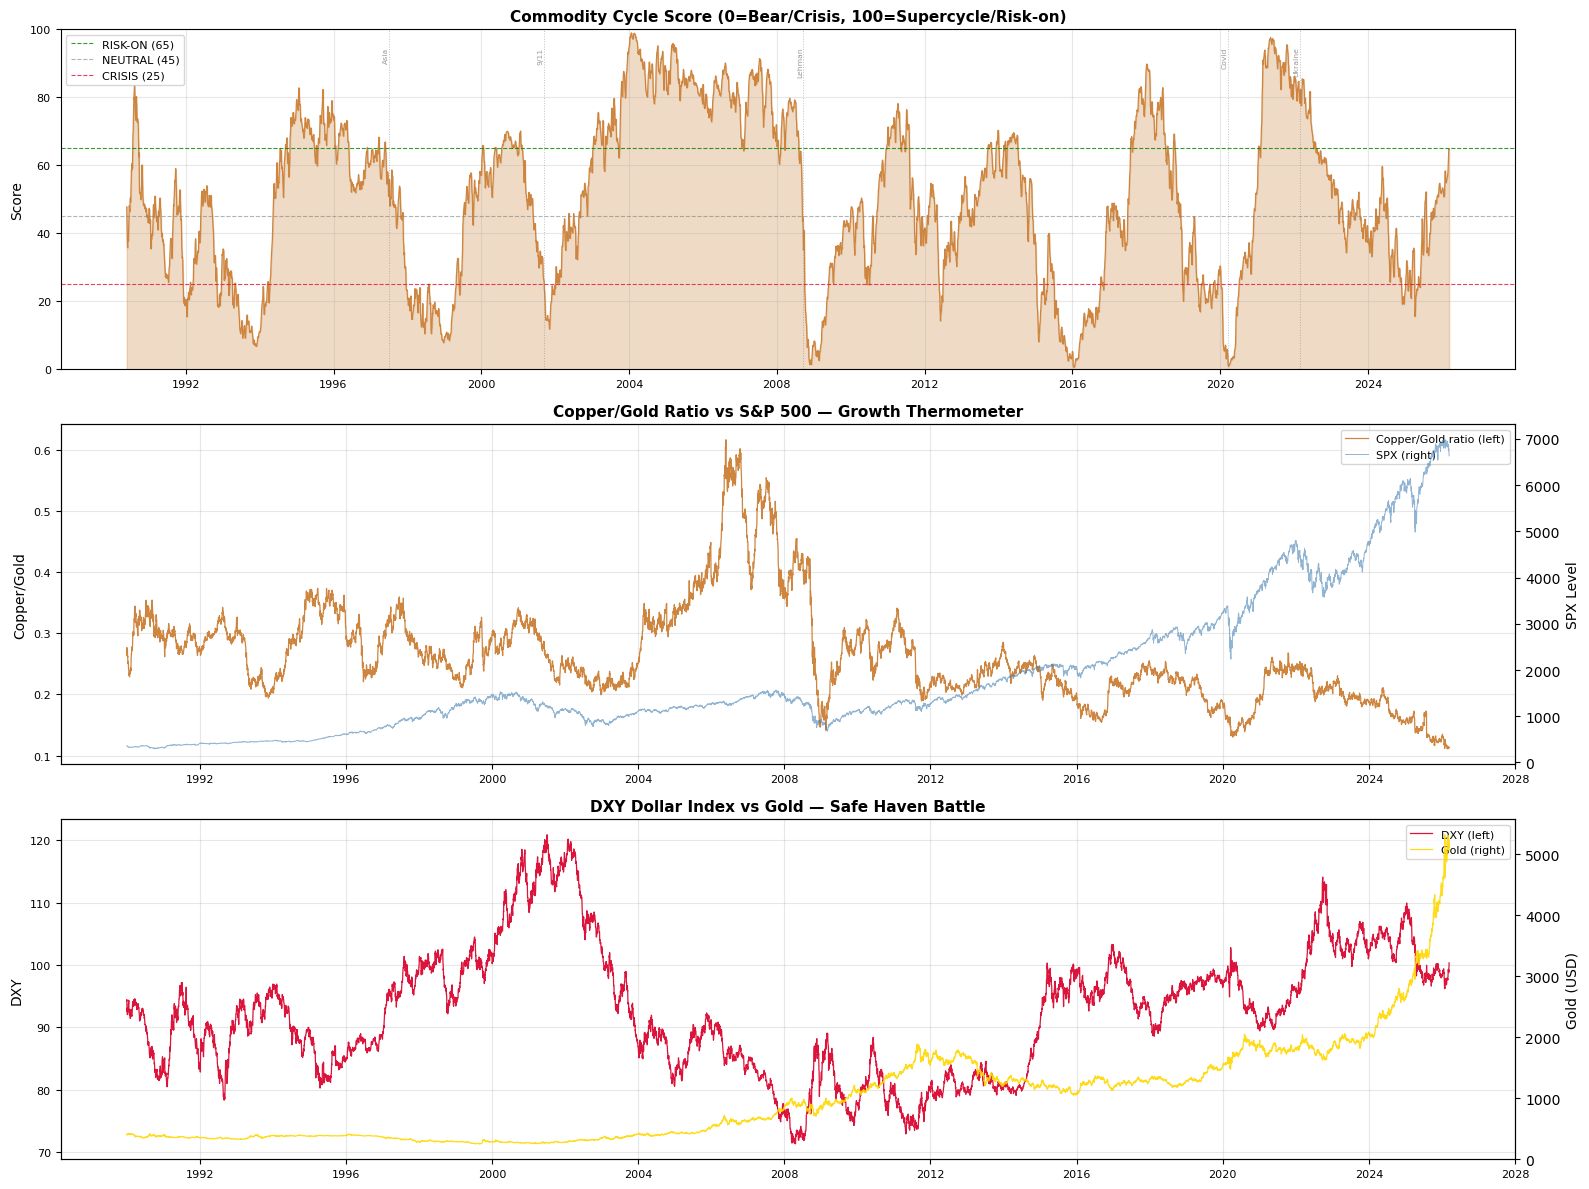


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\06_branch5_commod_score.png
Branch 5 output saved.


In [2]:
# ── Cell 2: Commodities & FX Score ───────────────────────────────────────────

def rolling_zscore(series, window=252, min_periods=63):
    m = series.rolling(window, min_periods=min_periods).mean()
    s = series.rolling(window, min_periods=min_periods).std()
    return (series - m) / s

def rolling_pctile(series, window=756, min_periods=126):
    return series.rolling(window, min_periods=min_periods).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1] * 100, raw=False
    )

# ── 2A: Z-score key commodity and FX indicators ───────────────────────────────
print("Commodities & FX Z-scores (current):")
print("-"*60)

# Commodities
print("\n  Commodities:")
for ticker, name in {**PRECIOUS_METALS, **INDUSTRIAL_METALS,
                     **ENERGY, **COMMODITY_INDICES}.items():
    s = comfx_prices[ticker].dropna()
    z = rolling_zscore(s).dropna().iloc[-1]
    lvl = s.iloc[-1]
    reg = "HIGH" if z > 1 else "LOW" if z < -1 else "NORMAL"
    bar = "█" * min(int(abs(z)*2), 10)
    print(f"    {name:<28} {lvl:>10.2f}  Z={z:>+5.2f}  {bar:<10}  [{reg}]")

# Key ratios
print("\n  Key Ratios:")
for series, name in [
    (copper_gold, "Copper/Gold (growth proxy)"),
    (gold_silver, "Gold/Silver (risk appetite)"),
]:
    z   = rolling_zscore(series).dropna().iloc[-1]
    cur = series.dropna().iloc[-1]
    reg = "HIGH" if z > 1 else "LOW" if z < -1 else "NORMAL"
    print(f"    {name:<30} {cur:>10.4f}  Z={z:>+5.2f}  [{reg}]")

# FX
print("\n  FX (Dollar and Safe Havens):")
for ticker, name in {**SAFE_HAVEN_FX, **MAJOR_FX}.items():
    s = comfx_prices[ticker].dropna()
    z = rolling_zscore(s).dropna().iloc[-1]
    lvl = s.iloc[-1]
    reg = "HIGH" if z > 1 else "LOW" if z < -1 else "NORMAL"
    print(f"    {name:<20} {lvl:>10.4f}  Z={z:>+5.2f}  [{reg}]")

print("\n  EM FX:")
for ticker, name in EM_FX.items():
    s = comfx_prices[ticker].dropna()
    z = rolling_zscore(s).dropna().iloc[-1]
    lvl = s.iloc[-1]
    # For USD/EM pairs: high Z = USD strong = EM under pressure
    stress = "EM STRESS" if z > 1 else "EM CALM" if z < -1 else "NEUTRAL"
    print(f"    {name:<26} {lvl:>10.4f}  Z={z:>+5.2f}  [{stress}]")


# ── 2B: Build the Commodity Cycle Score (0-100) ───────────────────────────────
# High score = commodity supercycle / risk-on / growth
# Low score  = commodity bear / risk-off / growth scare
#
# Key inputs:
#   Copper/Gold ratio    — growth vs safety
#   BCOM index level     — broad commodity strength
#   Oil level            — global demand proxy
#   Baltic Dry           — physical trade demand
#   AUDJPY               — carry/risk appetite

# All inputs: high value = more risk-on / growth positive
p_copper_gold = rolling_pctile(copper_gold)
p_bcom        = rolling_pctile(prices["BCOM Index"])
p_oil         = rolling_pctile(prices["CL1 Comdty"].clip(lower=1))
p_bdiy        = rolling_pctile(prices["BDIY Index"])
p_audjpy      = rolling_pctile(comfx_prices["AUDJPY Curncy"])

# Dollar score: high DXY = USD strength = commodity headwind = risk-off
# Invert so high = risk-on (weak dollar)
p_dxy_inv     = 100 - rolling_pctile(comfx_prices["DXY Curncy"])

COMMOD_WEIGHTS = {
    "copper_gold": 0.30,
    "bcom":        0.15,
    "oil":         0.15,
    "bdiy":        0.10,
    "audjpy":      0.20,
    "dxy_inv":     0.10,
}

commod_score  = pd.Series(0.0, index=comfx_prices.index)
weight_avail  = pd.Series(0.0, index=comfx_prices.index)

for series, key in [
    (p_copper_gold, "copper_gold"),
    (p_bcom,        "bcom"),
    (p_oil,         "oil"),
    (p_bdiy,        "bdiy"),
    (p_audjpy,      "audjpy"),
    (p_dxy_inv,     "dxy_inv"),
]:
    w     = COMMOD_WEIGHTS[key]
    valid = series.notna()
    commod_score[valid]  += series[valid] * w
    weight_avail[valid]  += w

commod_score = commod_score / weight_avail
commod_score = commod_score.rolling(5, min_periods=1).mean()
commod_score.name = "Commodity Cycle Score"

def classify_commod_regime(score):
    if   score >= 65: return "RISK-ON / GROWTH"
    elif score >= 45: return "NEUTRAL"
    elif score >= 25: return "RISK-OFF / SLOWDOWN"
    else:             return "COMMODITY BEAR / CRISIS"

commod_regime = commod_score.apply(classify_commod_regime)

cur_commod   = commod_score.dropna().iloc[-1]
cur_regime   = classify_commod_regime(cur_commod)
all_time_p   = (commod_score.dropna() < cur_commod).sum() / len(commod_score.dropna()) * 100

print(f"\nCommodity Cycle Score as of {commod_score.dropna().index[-1].date()}:")
print(f"  Score           : {cur_commod:.1f} / 100")
print(f"  Regime          : {cur_regime}")
print(f"  All-time pctile : {all_time_p:.1f}th percentile")
print(f"\nRegime distribution over full history:")
print(commod_regime.value_counts().to_string())


# ── 2C: Dollar regime ─────────────────────────────────────────────────────────
dxy_z = rolling_zscore(comfx_prices["DXY Curncy"]).dropna().iloc[-1]
dxy_cur = comfx_prices["DXY Curncy"].dropna().iloc[-1]

def classify_dollar(z):
    if   z >  1.0: return "STRONG — headwind for EM and commodities"
    elif z < -1.0: return "WEAK — tailwind for EM and commodities"
    else:          return "NEUTRAL"

print(f"\nDollar Regime:")
print(f"  DXY level : {dxy_cur:.2f}  Z={dxy_z:>+.2f}  [{classify_dollar(dxy_z)}]")

# ── 2D: EM stress composite ───────────────────────────────────────────────────
em_stress_scores = []
for ticker in EM_FX.keys():
    z = rolling_zscore(comfx_prices[ticker]).dropna()
    if not z.empty:
        em_stress_scores.append(z)

em_stress_avg = pd.concat(em_stress_scores, axis=1).mean(axis=1)
cur_em_stress = em_stress_avg.dropna().iloc[-1]
em_label = ("EM CRISIS" if cur_em_stress > 2 else
            "EM STRESS" if cur_em_stress > 1 else
            "EM CALM"   if cur_em_stress < -0.5 else "EM NEUTRAL")

print(f"\nEM FX Composite Stress:")
print(f"  Avg Z-score : {cur_em_stress:>+.2f}  [{em_label}]")


# ── 2E: Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Top: Commodity Cycle Score
ax1 = axes[0]
ax1.fill_between(commod_score.index, commod_score.values, alpha=0.3, color="peru")
ax1.plot(commod_score.index, commod_score.values, lw=0.9, color="peru")
ax1.axhline(65, color="green",   lw=0.8, ls="--", alpha=0.8, label="RISK-ON (65)")
ax1.axhline(45, color="grey",    lw=0.8, ls="--", alpha=0.6, label="NEUTRAL (45)")
ax1.axhline(25, color="crimson", lw=0.8, ls="--", alpha=0.8, label="CRISIS (25)")
for crisis_date, label in CRISES:
    try:
        ax1.axvline(pd.Timestamp(crisis_date), color="grey", lw=0.7, ls=":", alpha=0.5)
        ax1.text(pd.Timestamp(crisis_date), 95, label, fontsize=5.5,
                 rotation=90, va="top", ha="right", color="grey", alpha=0.8)
    except: pass
ax1.set_title("Commodity Cycle Score (0=Bear/Crisis, 100=Supercycle/Risk-on)",
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Score")
ax1.legend(fontsize=8, loc="upper left")
ax1.set_ylim(0, 100)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(labelsize=8); ax1.grid(alpha=0.3)

# Middle: Copper/Gold ratio with SPX overlay
ax2 = axes[1]
ax2_twin = ax2.twinx()
cg = copper_gold.dropna()
spx = prices["SPX Index"].dropna()
ax2.plot(cg.index, cg.values, lw=0.9, color="peru", label="Copper/Gold ratio (left)")
ax2_twin.plot(spx.index, spx.values, lw=0.7, color="steelblue",
              alpha=0.6, label="SPX (right)")
ax2.set_title("Copper/Gold Ratio vs S&P 500 — Growth Thermometer",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Copper/Gold")
ax2_twin.set_ylabel("SPX Level")
lines1, l1 = ax2.get_legend_handles_labels()
lines2, l2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1+lines2, l1+l2, fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(labelsize=8); ax2.grid(alpha=0.3)

# Bottom: DXY vs Gold
ax3 = axes[2]
ax3_twin = ax3.twinx()
dxy = comfx_prices["DXY Curncy"].dropna()
gold = comfx_prices["GC1 Comdty"].dropna()
ax3.plot(dxy.index, dxy.values, lw=0.9, color="crimson", label="DXY (left)")
ax3_twin.plot(gold.index, gold.values, lw=0.9, color="gold",
              alpha=0.9, label="Gold (right)")
ax3.set_title("DXY Dollar Index vs Gold — Safe Haven Battle",
              fontsize=11, fontweight="bold")
ax3.set_ylabel("DXY")
ax3_twin.set_ylabel("Gold (USD)")
lines1, l1 = ax3.get_legend_handles_labels()
lines2, l2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1+lines2, l1+l2, fontsize=8)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.tick_params(labelsize=8); ax3.grid(alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "06_branch5_commod_score.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

# ── Save Branch 5 output ──────────────────────────────────────────────────────
branch5_output = pd.DataFrame({
    "commod_score":    commod_score,
    "commod_regime":   commod_regime,
    "copper_gold":     copper_gold,
    "gold_silver":     gold_silver,
    "em_stress":       em_stress_avg,
    "dxy_zscore":      rolling_zscore(comfx_prices["DXY Curncy"]),
})
branch5_output.to_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "branch5_comfx_output.csv")
)
print("Branch 5 output saved.")

In [3]:
# ── Cell 3: Branch 5 Final Summary ───────────────────────────────────────────
from datetime import timedelta

latest = commod_score.dropna().index[-1]

# Load all previous branches
branch1 = pd.read_csv(os.path.join(cfg.PROC_PATH, "regimes", "branch1_fear_output.csv"),
                      index_col="date", parse_dates=True)
branch2 = pd.read_csv(os.path.join(cfg.PROC_PATH, "regimes", "branch2_credit_output.csv"),
                      index_col="date", parse_dates=True)
branch3 = pd.read_csv(os.path.join(cfg.PROC_PATH, "regimes", "branch3_equity_output.csv"),
                      index_col="date", parse_dates=True)
branch4 = pd.read_csv(os.path.join(cfg.PROC_PATH, "regimes", "branch4_rates_output.csv"),
                      index_col="date", parse_dates=True)

fear_now   = branch1["fear_score"].dropna().iloc[-1]
credit_now = branch2["credit_score"].dropna().iloc[-1]
pred_now   = branch3["pred_score"].dropna().iloc[-1]
rates_now  = branch4["rates_score"].dropna().iloc[-1]
commod_now = commod_score.dropna().iloc[-1]

# Regime streak
cur_regime = classify_commod_regime(commod_now)
streak = 0
for r in reversed(commod_regime.dropna().values):
    if r == cur_regime:
        streak += 1
    else:
        break

# Current key levels
gold_now  = comfx_prices["GC1 Comdty"].dropna().iloc[-1]
copp_now  = comfx_prices["HG1 Comdty"].dropna().iloc[-1]
oil_now   = comfx_prices["CL1 Comdty"].dropna().iloc[-1]
dxy_now   = comfx_prices["DXY Curncy"].dropna().iloc[-1]
audjpy_now= comfx_prices["AUDJPY Curncy"].dropna().iloc[-1]
cg_now    = copper_gold.dropna().iloc[-1]
cg_mean   = copper_gold.dropna().mean()
cg_z      = rolling_zscore(copper_gold).dropna().iloc[-1]
gs_now    = gold_silver.dropna().iloc[-1]
dxy_z     = rolling_zscore(comfx_prices["DXY Curncy"]).dropna().iloc[-1]
gold_z    = rolling_zscore(comfx_prices["GC1 Comdty"]).dropna().iloc[-1]

# Historical analogues
score_series = commod_score.dropna()
diffs        = (score_series - commod_now).abs().sort_values()
diffs        = diffs[diffs.index < (latest - timedelta(days=90))]

# Stagflation check: oil high + copper/gold low simultaneously
oil_z_cur   = rolling_zscore(prices["CL1 Comdty"].clip(lower=1)).dropna().iloc[-1]
stagflation = oil_z_cur > 1.5 and cg_z < -1.0
deflation   = oil_z_cur < -1.0 and cg_z < -1.0
goldilocks  = oil_z_cur < 1.0  and cg_z > 0

if stagflation:
    macro_signal = "STAGFLATION RISK — high energy costs + weak growth thermometer"
elif deflation:
    macro_signal = "DEFLATIONARY RISK — both oil and growth thermometer weak"
elif goldilocks:
    macro_signal = "GOLDILOCKS — balanced growth and energy"
else:
    macro_signal = "MIXED — monitor divergences"

print("=" * 65)
print("   BRANCH 5 — COMMODITIES & FX REPORT")
print(f"   As of {latest.date()}")
print("=" * 65)

print(f"\n  COMMODITY SCORE  :  {commod_now:.1f} / 100")
print(f"  REGIME           :  {cur_regime}")
print(f"  REGIME STREAK    :  {streak} days")
print(f"  ALL-TIME PCTILE  :  {all_time_p:.1f}th percentile")

print(f"\n  ── Key Commodity Levels ────────────────────────────")
print(f"  Gold    : ${gold_now:>8.2f}  Z={rolling_zscore(comfx_prices['GC1 Comdty']).dropna().iloc[-1]:>+.2f}")
print(f"  Copper  : ${copp_now:>8.2f}  Z={rolling_zscore(comfx_prices['HG1 Comdty']).dropna().iloc[-1]:>+.2f}")
print(f"  WTI Oil : ${oil_now:>8.2f}  Z={rolling_zscore(prices['CL1 Comdty'].clip(lower=1)).dropna().iloc[-1]:>+.2f}")

print(f"\n  ── Growth Thermometers ─────────────────────────────")
print(f"  Copper/Gold ratio : {cg_now:.4f}  Z={cg_z:>+.2f}  "
      f"(mean: {cg_mean:.4f}  |  {cg_now/cg_mean*100:.0f}% of mean)")
print(f"  Gold/Silver ratio : {gs_now:.2f}  Z={rolling_zscore(gold_silver).dropna().iloc[-1]:>+.2f}")
print(f"  Baltic Dry        : {comfx_prices['BDIY Index'].dropna().iloc[-1]:,.0f}  "
      f"Z={rolling_zscore(comfx_prices['BDIY Index']).dropna().iloc[-1]:>+.2f}")

print(f"\n  ── Dollar and FX ───────────────────────────────────")
print(f"  DXY     : {dxy_now:.2f}  Z={dxy_z:>+.2f}  [{classify_dollar(dxy_z)}]")
print(f"  USDJPY  : {comfx_prices['USDJPY Curncy'].dropna().iloc[-1]:.2f}  "
      f"Z={rolling_zscore(comfx_prices['USDJPY Curncy']).dropna().iloc[-1]:>+.2f}")
print(f"  AUDJPY  : {audjpy_now:.2f}  "
      f"Z={rolling_zscore(comfx_prices['AUDJPY Curncy']).dropna().iloc[-1]:>+.2f}")
print(f"  EM FX   : avg Z={em_stress_avg.dropna().iloc[-1]:>+.2f}  [{em_label}]")

print(f"\n  ── Macro Signal ────────────────────────────────────")
print(f"  {macro_signal}")
print(f"\n  Gold+DXY both elevated : {'YES — dual safe haven bid' if gold_z > 1 and dxy_z > 1 else 'No'}")

print(f"\n  ── Cross-Branch Scorecard ──────────────────────────")
print(f"  Fear     (B1) : {fear_now:>5.1f}   ACUTE")
print(f"  Credit   (B2) : {credit_now:>5.1f}   BENIGN")
print(f"  Equity   (B3) : {pred_now:>5.1f}   MODERATE")
print(f"  Rates    (B4) : {rates_now:>5.1f}   EASING")
print(f"  Commod   (B5) : {commod_now:>5.1f}   {cur_regime}")

print(f"\n  ── Historical Analogues ────────────────────────────")
shown = []
for date, diff in diffs.items():
    if all(abs((date - d).days) > 60 for d in shown):
        fear_then = branch1["fear_score"].get(date, float("nan"))
        cg_then   = copper_gold.get(date, float("nan"))
        oil_then  = prices["CL1 Comdty"].get(date, float("nan"))
        gold_then = comfx_prices["GC1 Comdty"].get(date, float("nan"))
        print(f"  {str(date.date())}  Commod={score_series.get(date,0):.1f}  "
              f"Fear={fear_then:.1f}  CG={cg_then:.4f}  "
              f"Oil=${oil_then:.0f}  Gold=${gold_then:.0f}")
        shown.append(date)
    if len(shown) >= 5:
        break

print("\n" + "=" * 65)
print("  Branch 5 complete. Output saved to data/processed/regimes/")
print("=" * 65)

   BRANCH 5 — COMMODITIES & FX REPORT
   As of 2026-03-13

  COMMODITY SCORE  :  64.7 / 100
  REGIME           :  NEUTRAL
  REGIME STREAK    :  109 days
  ALL-TIME PCTILE  :  68.2th percentile

  ── Key Commodity Levels ────────────────────────────
  Gold    : $ 5061.70  Z=+1.78
  Copper  : $  571.45  Z=+1.14
  WTI Oil : $   98.71  Z=+5.89

  ── Growth Thermometers ─────────────────────────────
  Copper/Gold ratio : 0.1129  Z=-1.41  (mean: 0.2656  |  42% of mean)
  Gold/Silver ratio : 62.56  Z=-1.21
  Baltic Dry        : 2,028  Z=+0.43

  ── Dollar and FX ───────────────────────────────────
  DXY     : 100.36  Z=+1.45  [STRONG — headwind for EM and commodities]
  USDJPY  : 159.73  Z=+1.83
  AUDJPY  : 111.51  Z=+2.01
  EM FX   : avg Z=-0.03  [EM NEUTRAL]

  ── Macro Signal ────────────────────────────────────
  STAGFLATION RISK — high energy costs + weak growth thermometer

  Gold+DXY both elevated : YES — dual safe haven bid

  ── Cross-Branch Scorecard ──────────────────────────
  Fea